In [1]:
from TKA_JGA_Mo_250111_EoS_2 import calc_eq, dfg, phi_Soave, delta_f_G
import numpy as np
import matplotlib.pyplot as plt

## Alvarez 2017: here also these jumps seeable

In [2]:
x_0 = np.array([
    0.25, # CO2
    0.75-5e-20, # H2
    1e-20, # H2O
    1e-20,
    1e-20,
    1e-20,
])

x_1 = np.array([
    0.25, # CO2
    0.75, # H2
    0, # H2O
    0,
    0,
    0,
])

x = np.vstack([x_0, x_1])

In [3]:
x.shape

(2, 6)

In [4]:
T = np.linspace(100, 400, 25) + 273.15
p = np.array(([1, 10, 30, 50, 100])) * 1e5
x_0_G = np.array([
    0.25, # CO2
    0.75-4e-20, # H2
    1e-20, # H2O
    1e-20,
    1e-20,
    1e-20,
    #1e-20,
    #1e-20,
])

x_0_L = np.array([
    1e-20, # H2O
    1e-20, # MeOH
    #1e-20, # H2O
    #1e-20,
    #1e-20,
    #1e-20,
    #0,
    #0,
])

In [5]:
x_0 = np.hstack([x_0_G, x_0_L])
x_0.shape

(8,)

# gE-Modell

In [6]:
'''counter = 0
x_eq = np.zeros((len(p), len(T), x_0_G.shape[0]))
#x_G_eq = np.zeros((len(p), len(T), x_0_G.shape[0]))
#x_L_eq = np.zeros((len(p), len(T), x_0_L.shape[0]))
X_CO2 = np.zeros((len(p), len(T)))
S_MeOH = np.zeros((len(p), len(T)))
for i in range(len(p)):
    for j in range(len(T)):
        x_eq[i, j, :], succ, g_T_val, n_eq_val = calc_eq(T[j], p[i], x_0_G, 'real gas')
        #x_G_eq[i, j, :] = x_eq[i, j, :6]
        #x_L_eq[i, j, :] = x_eq[i, j, 6:]
        X_CO2[i, j] = (x_0[0] - n_eq_val[0]) / x_0[0]
        S_MeOH[i, j] = - ((x_0[4] + x_0[-1]) - (n_eq_val[4] + n_eq_val[-1])) / (x_0[0] - n_eq_val[0])'''

"counter = 0\nx_eq = np.zeros((len(p), len(T), x_0_G.shape[0]))\n#x_G_eq = np.zeros((len(p), len(T), x_0_G.shape[0]))\n#x_L_eq = np.zeros((len(p), len(T), x_0_L.shape[0]))\nX_CO2 = np.zeros((len(p), len(T)))\nS_MeOH = np.zeros((len(p), len(T)))\nfor i in range(len(p)):\n    for j in range(len(T)):\n        x_eq[i, j, :], succ, g_T_val, n_eq_val = calc_eq(T[j], p[i], x_0_G, 'real gas')\n        #x_G_eq[i, j, :] = x_eq[i, j, :6]\n        #x_L_eq[i, j, :] = x_eq[i, j, 6:]\n        X_CO2[i, j] = (x_0[0] - n_eq_val[0]) / x_0[0]\n        S_MeOH[i, j] = - ((x_0[4] + x_0[-1]) - (n_eq_val[4] + n_eq_val[-1])) / (x_0[0] - n_eq_val[0])"

# Equation of State

In [7]:
counter = 0
x_eq = np.zeros((len(p), len(T), x_0.shape[0]))
x_G_eq = np.zeros((len(p), len(T), x_0_G.shape[0]))
n_eq = np.zeros((len(p), len(T), x_0.shape[0]))
x_L_eq = np.zeros((len(p), len(T), x_0_L.shape[0]))
X_CO2 = np.zeros((len(p), len(T)))
S_MeOH = np.zeros((len(p), len(T)))
for i in range(len(p)):
    for j in range(len(T)):
        #x_eq[i, j, :], succ, g_T_val, n_eq_val = calc_eq(T[j], p[i], x_0, 'ideal gas')
        _, _, _, n_eq[i, j, :] = calc_eq(T[j], p[i], x_0, 'real gas')
        #x_G_eq[i, j, :] = x_eq[i, j, :6]
        #x_L_eq[i, j, :] = x_eq[i, j, 6:]
        X_CO2[i, j] = (x_0[0] - n_eq[i, j, 0]) / x_0[0]
        #S_MeOH[i, j] = - ((x_0[4] + x_0[-1]) - (n_eq_val[4] + n_eq_val[-1])) / (x_0[0] - n_eq_val[0])

/Users/johannesgeri/Documents/Master/HiWi/ANNs/gibbsenergyminimizationmodel/TKA_Mo_fug_coeffs_MeOH.py:131: RuntimeWarning: invalid value encountered in log
  res_liq = np.exp(ratio_b_liq * (Z_liq - 1) - np.log(Z_liq - B_L) - A_L / B_L * (2 * ratio_a_liq - ratio_b_liq) * np.log(1 + B_L / Z_liq)) # array of fugacity coefficients in 1


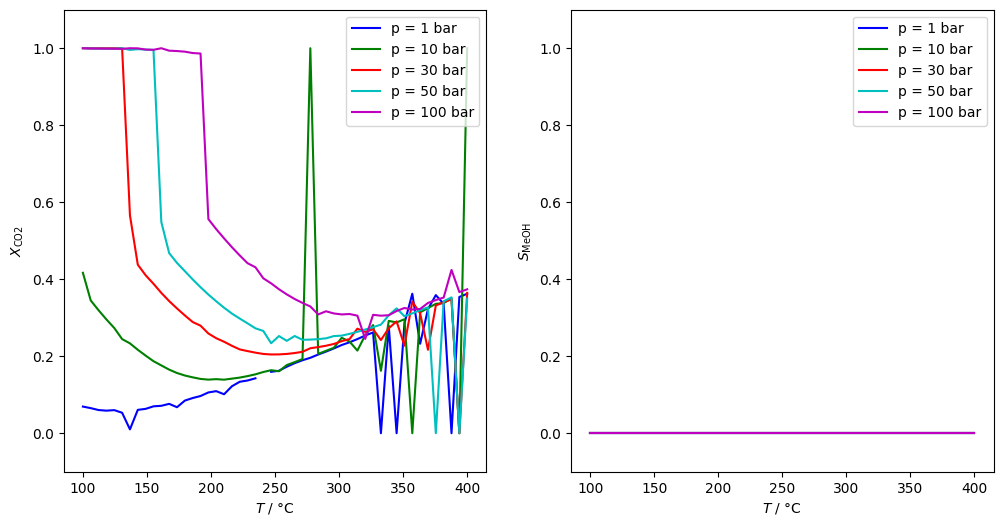

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))


species = ['CO2', 'H2', 'H2O', 'CO', 'MeOH', 'N2', 'MeOH_L', 'H2O_L']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'limegreen']

for j in range(len(p)):
    #plt.plot(T-273.15, x_eq[0, :, j], label=species[j], color=colors[j])
    # plot X_CO2
    ax[0].plot(T-273.15, X_CO2[j, :], label=f'p = {p[j]/1e5:.0f} bar', color=colors[j])
    # plot S_MeOH
    ax[1].plot(T-273.15, S_MeOH[j, :], label=f'p = {p[j]/1e5:.0f} bar', color=colors[j])

ax[0].set_xlabel(r'$T$ / °C')
ax[1].set_xlabel(r'$T$ / °C')
ax[0].set_ylim(-0.1, 1.1)
ax[1].set_ylim(-0.1, 1.1)
ax[0].set_ylabel(r'$X_{\mathrm{CO2}}$')
ax[1].set_ylabel(r'$S_{\mathrm{MeOH}}$')
ax[0].legend()
ax[1].legend()
plt.show()

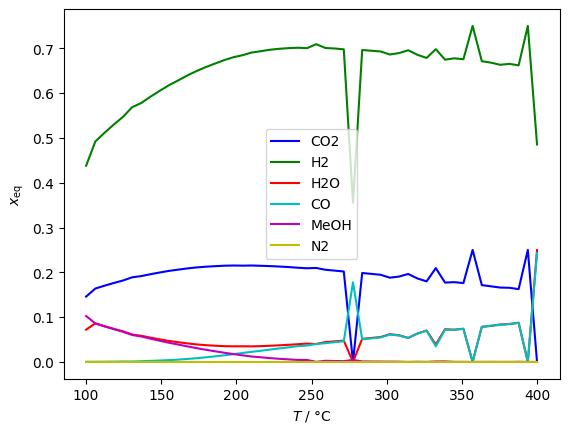

In [9]:
for j in range(len(x_0_G)):
    plt.plot(T-273.15, n_eq[1, :, j], label=species[j], color=colors[j])

plt.xlabel(r'$T$ / °C')
plt.ylabel(r'$x_{\mathrm{eq}}$')
plt.legend()

plt.show()